# Diurnal case-study figure
Four World Cup games shown against their stadium × day-of-year (±7 d) **1960–1990 diurnal WBGT climatology**. Each panel shows the climatological mean and the 75th/90th/95th percentiles and the record (max) per local hour, the actual game-day hourly WBGT, the game window (kickoff−1 h … kickoff+3 h), and the 26/28/32 °C reference lines. Data are pre-computed in `data/processed/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# set ROOT to the bundle path if you move this notebook
ROOT = "/glade/derecho/scratch/gavinmad/shared/Heathack"
PROC = os.path.join(ROOT, "data", "processed")
plt.rcParams.update({"font.size": 13, "figure.dpi": 120})

In [2]:
clim = pd.read_csv(os.path.join(PROC, "case_study_diurnal_clim.csv"))
act  = pd.read_csv(os.path.join(PROC, "case_study_diurnal_actual.csv"))
meta = pd.read_csv(os.path.join(PROC, "case_study_diurnal_meta.csv"))
meta

,case,label,gender,year,city,stadium,match_date,time_local,ko_h,win_lo,...,day_mean,day_min,day_max,hrs_ge26,hrs_ge28,hrs_ge32,hrs_p75,hrs_p90,hrs_p95,hrs_max
0,0,Washington 1994 — USA'94 (hottest window),Men,1994,Washington,RFK Stadium,1994-06-19,16:00:00,16,15,...,27.44,22.47,35.87,5,4,3,5,5,4,3
1,1,Al Wakrah 2022 — TUN–AUS (hot afternoon),Men,2022,Al Wakrah,Al Janoub Stadium,2022-11-26,13:00:00,13,12,...,23.34,19.88,30.11,5,3,0,5,5,5,3
2,2,Sochi 2018 — mild but record-breaking,Men,2018,Sochi,Olimpiyskiy Stadion Fisht,2018-06-30,21:00:00,21,20,...,23.56,19.70,27.40,0,0,0,5,5,5,5
3,3,Cologne 2006 — quiet baseline game,Men,2006,Cologne,RheinEnergieSTADION,2006-06-23,21:00:00,21,20,...,15.48,9.16,22.39,0,0,0,0,0,0,0


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/diurnal_case_study.png


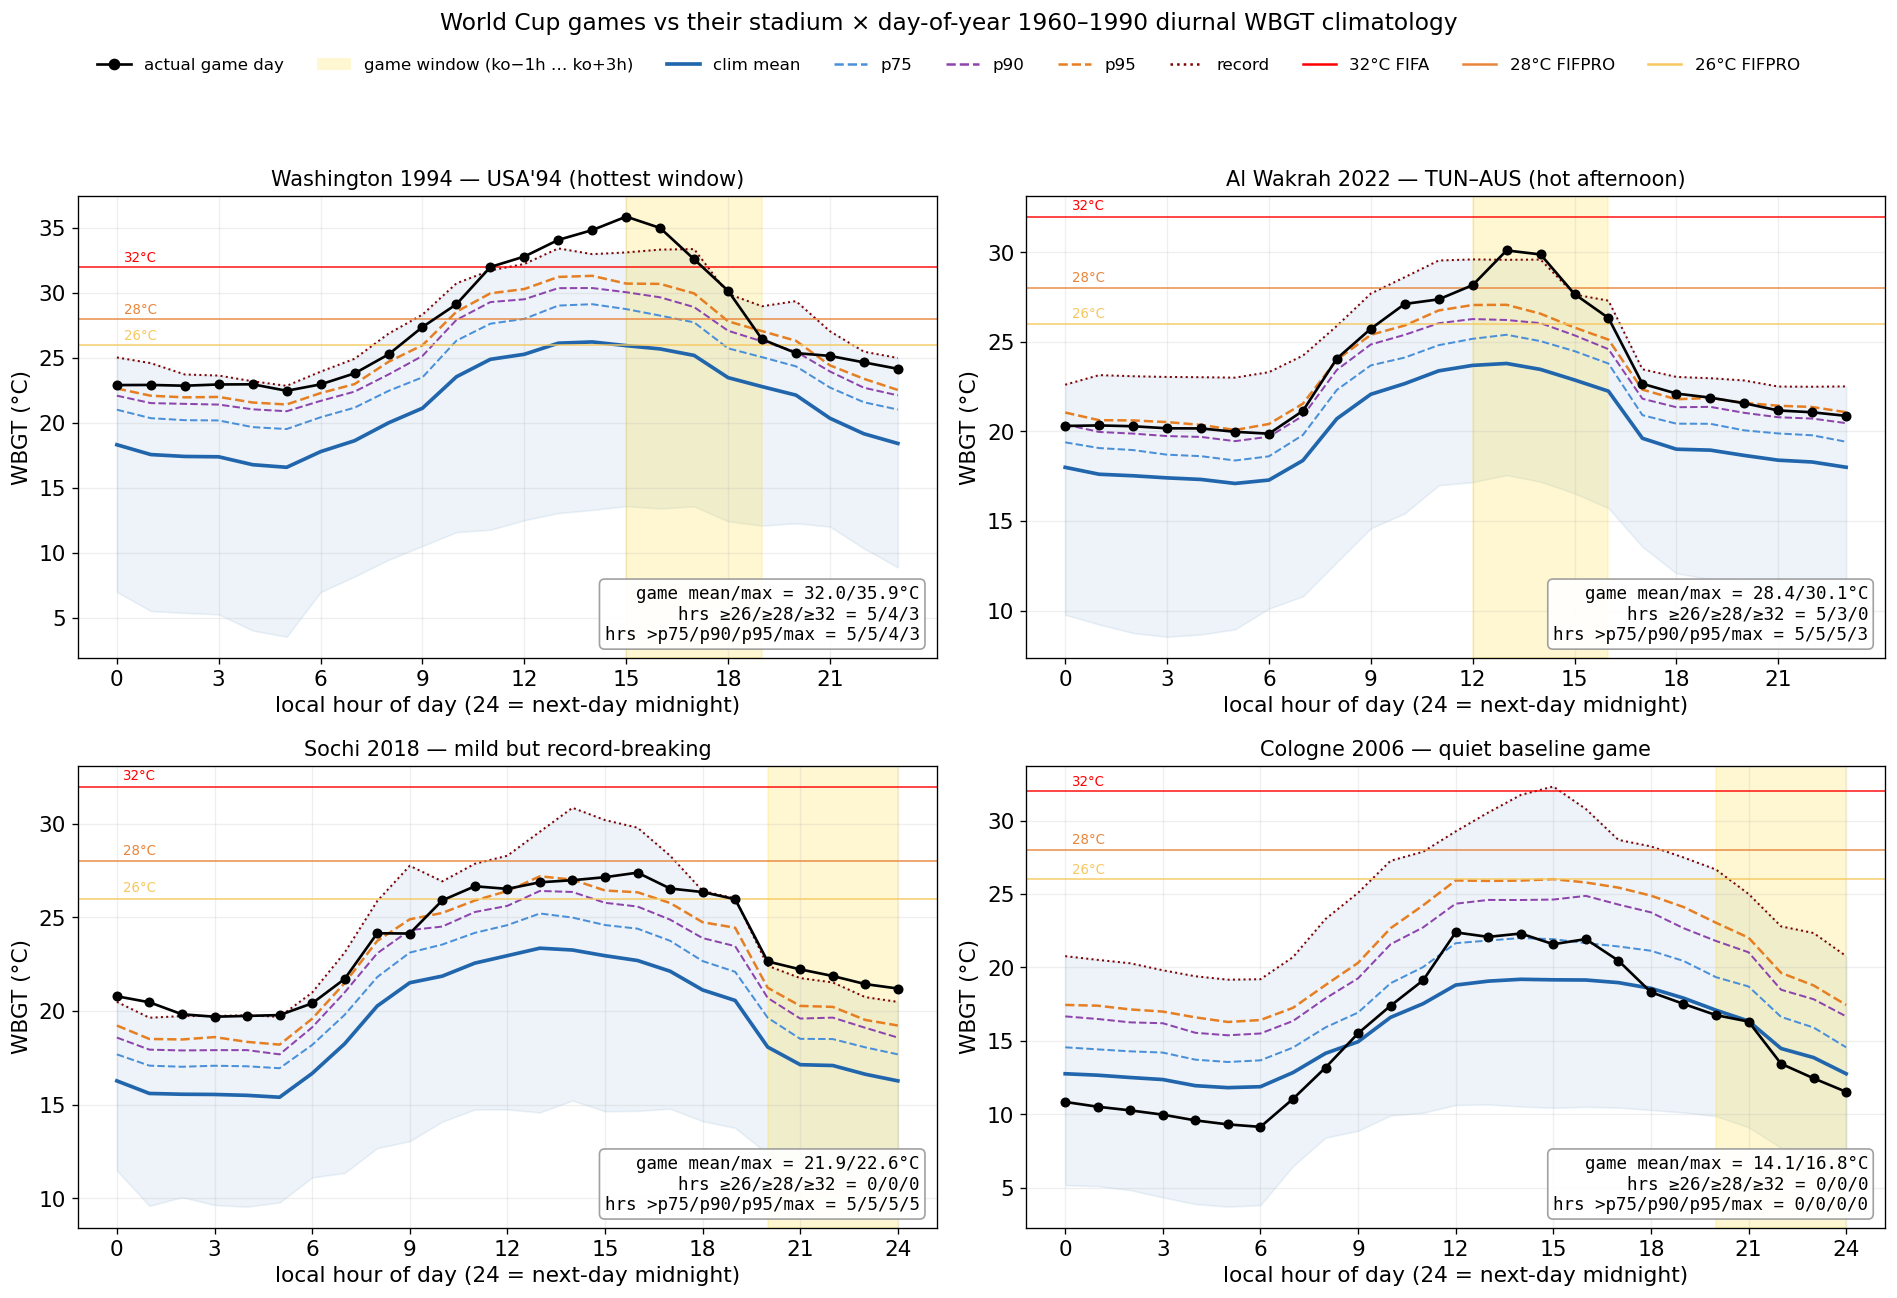

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10.5))
for ax, m in zip(axes.ravel(), meta.itertuples()):
    c = clim[clim.case == m.case].sort_values("ph"); a = act[act.case == m.case].sort_values("ph")
    ax.fill_between(c.ph, c.clim_min, c.clim_max, color="#2166ac", alpha=0.08, label="1960–1990 full range")
    ax.plot(c.ph, c.clim_mean, color="#2166ac", lw=2.2, label="clim mean")
    ax.plot(c.ph, c.clim_p75, color="#4a90d9", lw=1.2, ls="--", label="clim p75")
    ax.plot(c.ph, c.clim_p90, color="#8e44ad", lw=1.2, ls="--", label="clim p90")
    ax.plot(c.ph, c.clim_p95, color="#e67e22", lw=1.5, ls="--", label="clim p95")
    ax.plot(c.ph, c.clim_max, color="#7f0000", lw=1.2, ls=":", label="clim record (max)")
    for thr, cc in [(26, "#f6c85f"), (28, "#e8853a"), (32, "red")]:
        ax.axhline(thr, color=cc, lw=1.0, alpha=0.85); ax.text(0.2, thr + 0.2, f"{thr}°C", color=cc, fontsize=8, va="bottom")
    ax.axvspan(m.win_lo, m.win_hi, color="gold", alpha=0.18)
    ax.plot(a.ph, a.wbgt_actual, "o-", color="black", ms=5, lw=1.6, zorder=6, label="actual game day")
    box = (f"game mean/max = {m.game_mean:.1f}/{m.game_max:.1f}°C\n"
           f"hrs ≥26/≥28/≥32 = {m.hrs_ge26}/{m.hrs_ge28}/{m.hrs_ge32}\n"
           f"hrs >p75/p90/p95/max = {m.hrs_p75}/{m.hrs_p90}/{m.hrs_p95}/{m.hrs_max}")
    ax.text(0.98, 0.03, box, transform=ax.transAxes, ha="right", va="bottom", fontsize=10.5,
            family="monospace", bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.92))
    ax.set_title(m.label, fontsize=12.5)
    ax.set_xticks(range(0, int(m.maxph) + 1, 3)); ax.grid(alpha=0.2)
    ax.set_xlabel("local hour of day (24 = next-day midnight)"); ax.set_ylabel("WBGT (°C)")
handles = [Line2D([], [], color="black", marker="o", lw=1.6, label="actual game day"),
           Patch(facecolor="gold", alpha=0.18, label="game window (ko−1h … ko+3h)"),
           Line2D([], [], color="#2166ac", lw=2.2, label="clim mean"),
           Line2D([], [], color="#4a90d9", ls="--", label="p75"), Line2D([], [], color="#8e44ad", ls="--", label="p90"),
           Line2D([], [], color="#e67e22", ls="--", label="p95"), Line2D([], [], color="#7f0000", ls=":", label="record"),
           Line2D([], [], color="red", label="32°C FIFA"), Line2D([], [], color="#e8853a", label="28°C FIFPRO"),
           Line2D([], [], color="#f6c85f", label="26°C FIFPRO")]
fig.legend(handles=handles, loc="upper center", ncol=10, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.005))
fig.suptitle("World Cup games vs their stadium × day-of-year 1960–1990 diurnal WBGT climatology", fontsize=14, y=1.03)
fig.tight_layout(rect=[0, 0, 1, 0.96])
out = os.path.join(ROOT, "figures/03_climatology/diurnal_case_study.png")
fig.savefig(out, dpi=160, bbox_inches="tight"); print("wrote", out)